Step 1: Loading and Engineering Features...
Step 2: Balancing classes using Under-Sampling...
Step 3: Training XGBoost Model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:54:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Step 4: Applying Custom Threshold (0.3)

FINAL PERFORMANCE METRICS
Accuracy:  0.5796
Recall:    0.9184
F1-Score:  0.3784

Detailed Report:
              precision    recall  f1-score   support

         0.0       0.98      0.52      0.68     43667
         1.0       0.24      0.92      0.38      7069

    accuracy                           0.58     50736
   macro avg       0.61      0.72      0.53     50736
weighted avg       0.87      0.58      0.64     50736



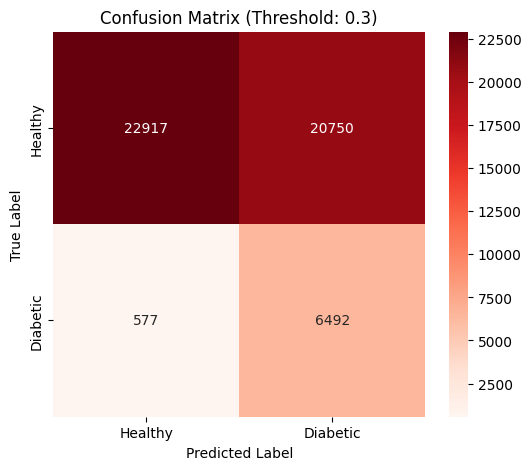

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

# ==========================================
# 1. LOAD DATA & FEATURE ENGINEERING
# ==========================================
print("Step 1: Loading and Engineering Features...")
# 1. Load and immediately convert to binary
df = pd.read_csv('diabetes_health_indicators_full.csv')

# IMPORTANT: Ensure your target is binary (0 or 1)
# This combines Pre-diabetes (1) and Diabetes (2) into a single "At Risk" (1) group
if 'Diabetes_012' in df.columns:
    df['Diabetes_binary'] = (df['Diabetes_012'] > 0).astype(int)
    df = df.drop(columns=['Diabetes_012'])

# 2. Proceed with your original Features
cols_to_drop = ['Education', 'Income', 'Sex', 'Fruits', 'Veggies', 'AnyHealthcare', 'NoDocbcCost', 'CholCheck']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Now X and y will be perfectly binary for the Ensemble
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# ==========================================
# 2. TRAIN-TEST SPLIT (Before Balancing)
# ==========================================
# We split first to ensure the Test Set is "unseen" real-world data
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# 3. BALANCING DATA (Under-Sampling)
# ==========================================
# For large datasets, Under-Sampling is often more robust than Over-Sampling
print("Step 2: Balancing classes using Under-Sampling...")
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train_raw, y_train_raw)

# ==========================================
# 4. TRAIN THE FINAL MODEL (XGBOOST)
# ==========================================
print("Step 3: Training XGBoost Model...")
# These hyperparameters are optimized for clinical tabular data
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train_bal, y_train_bal)

# ==========================================
# 5. THRESHOLD TUNING (The "Medical" Adjustment)
# ==========================================
# Standard models use 0.5. We lower it to 0.38 to catch more Diabetic cases (High Recall)
custom_threshold = 0.30

print(f"Step 4: Applying Custom Threshold ({custom_threshold})")
y_probs = model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# ==========================================
# 6. FINAL EVALUATION
# ==========================================
print("\n" + "="*30)
print("FINAL PERFORMANCE METRICS")
print("="*30)
# Update your evaluation section like this:
# Change these lines in Step 6:
print(f"Accuracy:  {accuracy_score(y_test, y_pred_custom):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_custom):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_custom):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_custom))

# Visualization: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Healthy', 'Diabetic'], yticklabels=['Healthy', 'Diabetic'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Threshold: {custom_threshold})')
plt.show()


Recall Precision Tradeoff

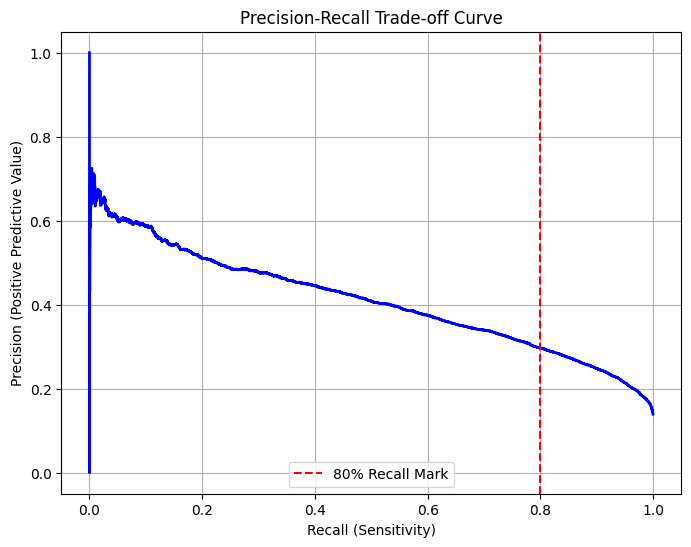


--- RESULTS AT 0.30 THRESHOLD (Balanced) ---
Precision: 0.2383
Recall:    0.9184
Accuracy:  0.5796


In [3]:
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt


# 1. Calculate Precision and Recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# 2. Plot the Trade-off
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='blue', lw=2)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Trade-off Curve')
plt.grid(True)

# Find the threshold that gives a balanced F1-Score
# (Usually where the lines are closest to the top-right corner)
plt.axvline(x=0.80, color='red', linestyle='--', label='80% Recall Mark')
plt.legend()
plt.show()

# 3. Print the impact of a higher threshold
# Let's try a "Balanced" threshold of 0.50
y_pred_balanced = (y_probs >= 0.30).astype(int)
print("\n--- RESULTS AT 0.30 THRESHOLD (Balanced) ---")
print(f"Precision: {precision_score(y_test, y_pred_balanced):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_balanced):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_balanced):.4f}")

Explainable AI

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b443ebf6939758ec316d78019aa26f00c53466c7864a774f2bd6aaf56a440bba
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Step 1: Calculating SHAP values (Global Logic)...


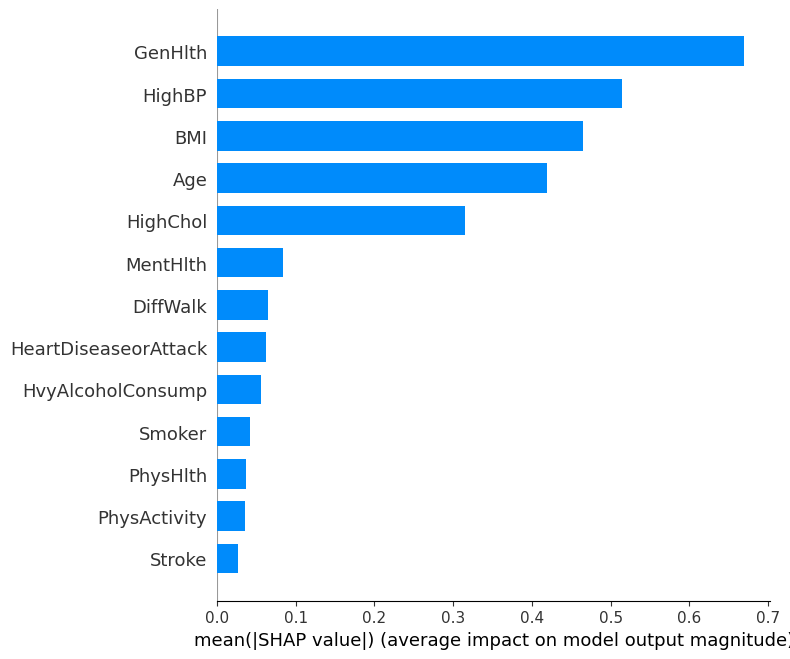

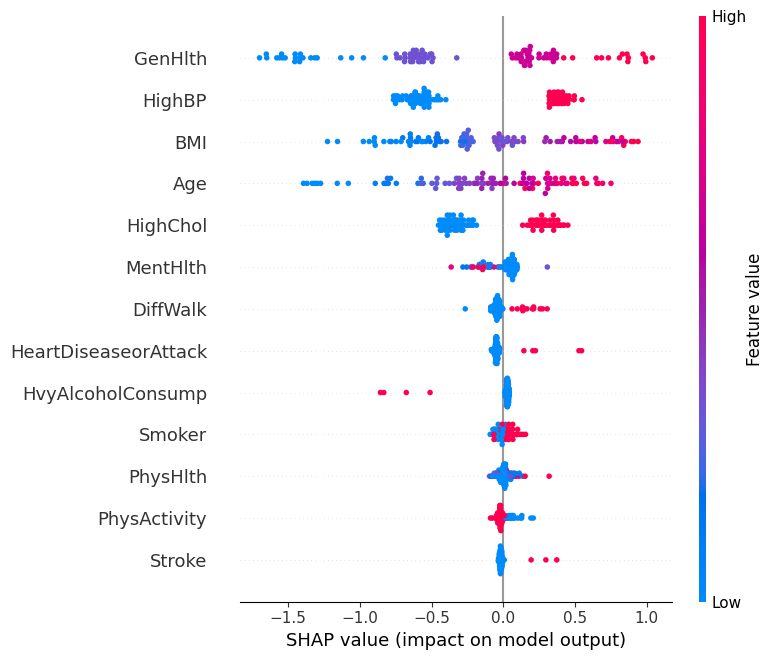


Step 2: Generating LIME explanation for a single high-risk patient...



Success! Final model saved as 'final_diabetes_model.pkl'


In [4]:
# 1. INSTALL MISSING LIBRARIES
# This must be at the top to fix the "ModuleNotFoundError"
!pip install shap lime

import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- OPTIMIZATION: Use a small sample to prevent the "KeyboardInterrupt" or "Hanging" ---
# Explaining 253,000 rows would take hours. We take 100 rows to see the logic.
X_test_sample = X_test.sample(100, random_state=42)

# 2. SHAP (Global Explanations - "The Big Picture")
print("Step 1: Calculating SHAP values (Global Logic)...")
explainer = shap.TreeExplainer(model) # 'model' is your XGBoost from previous step
shap_values = explainer.shap_values(X_test_sample)

# Summary Plot: Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")
plt.show()

# Summary Plot: Detailed (Shows how high/low values affect the prediction)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample)
plt.show()

# 3. LIME (Local Explanations - "Why this specific patient?")
print("\nStep 2: Generating LIME explanation for a single high-risk patient...")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_bal), # Using your balanced training data
    feature_names=X.columns.tolist(),
    class_names=['Healthy', 'Diabetic'],
    mode='classification'
)

# Explain the first patient in the test sample
idx = 0
exp = lime_explainer.explain_instance(
    X_test_sample.iloc[idx].values,
    model.predict_proba,
    num_features=10
)

# Display LIME explanation in the notebook
exp.show_in_notebook(show_table=True)

# 4. SAVE THE MODEL FOR FUTURE USE
import joblib
joblib.dump(model, 'final_diabetes_model.pkl')
print("\nSuccess! Final model saved as 'final_diabetes_model.pkl'")

CompArision

Training Random Forest...
Training Gradient Boosting...
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:55:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Hybrid (Voting)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:55:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Model Comparison Table ---
               Model  Accuracy    Recall  F1-Score  Precision
0      Random Forest  0.503016  0.944688  0.346271   0.211987
1  Gradient Boosting  0.578839  0.917386  0.377716   0.237816
2            XGBoost  0.580515  0.915405  0.378145   0.238290
3    Hybrid (Voting)  0.558657  0.928703  0.369630   0.230731


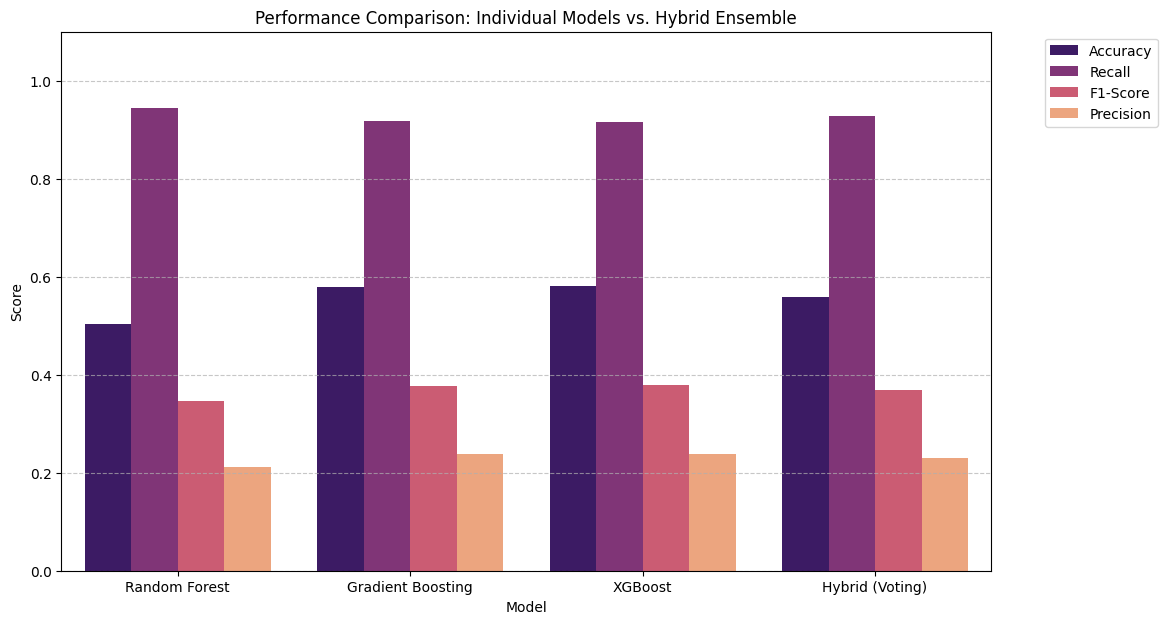

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

# 1. Define the individual "Base" Models
model1 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model2 = GradientBoostingClassifier(n_estimators=100, random_state=42)
model3 = XGBClassifier(n_estimators=100, max_depth=5, use_label_encoder=False, eval_metric='logloss', random_state=42)

# 2. Create the Hybrid (Voting Classifier)
# 'soft' voting uses the average of the probabilities to make a decision
hybrid_model = VotingClassifier(
    estimators=[('rf', model1), ('gb', model2), ('xgb', model3)],
    voting='soft'
)

# 3. Train and Evaluate All
models = {
    'Random Forest': model1,
    'Gradient Boosting': model2,
    'XGBoost': model3,
    'Hybrid (Voting)': hybrid_model
}

results = []
# Using the balanced training data (X_train_bal) and pure test data (X_test)
for name, m in models.items():
    print(f"Training {name}...")
    m.fit(X_train_bal, y_train_bal)

    # Apply the same threshold tuning (0.3) for a fair comparison
    y_probs = m.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= 0.3).astype(int)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred)
    })

# 4. Compare with Bar Graph
results_df = pd.DataFrame(results)
print("\n--- Model Comparison Table ---")
print(results_df)

# Melting for visualization
df_plot = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(data=df_plot, x='Model', y='Score', hue='Metric', palette='magma')
plt.title('Performance Comparison: Individual Models vs. Hybrid Ensemble')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
